In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [129]:
df=pd.read_csv(r"california_housing.csv")
X=df[['AveRooms']]
y=df[['MedHouseVal']]

In [130]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [131]:
model=LinearRegression()
model.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.08]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['AveRooms']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[1.65]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [132]:
print('Intercept:',model.intercept_)
print('Slope:',model.coef_)


Intercept: [1.65476227]
Slope: [[0.07675559]]


In [133]:
y_pred=model.predict(X_test)


In [134]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print('MSE:',mse)
print('R2:',r2)

MSE: 1.2923314440807299
R2: 0.013795337532284901


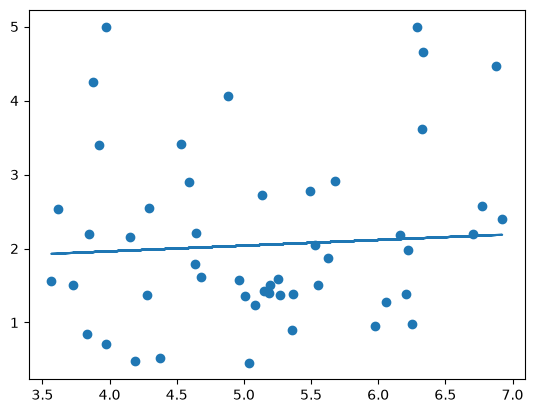

In [135]:
plt.scatter(X_test[:50],y_test[:50])
plt.plot(X_test[:50],y_pred[:50])

In [136]:
X1=df['AveRooms'].values
y=df['MedHouseVal'].values

In [137]:
X1=(X1-np.min(X1))/((np.max(X1))-(np.min(X1)))

In [138]:
X1_train,X1_test,y1_train,y1_test=train_test_split(
    X1,y,test_size=0.2,random_state=42)

In [139]:
theta0=0
theta1=0
n=len(X1_train)

cost_history=[]
learning_rate=0.01
iterations=1000


In [140]:
for i in range(iterations):
    y_pred=theta0+theta1*X1_train
    error= y1_train-y_pred
    d_theta0=(-2/n)*np.sum(error)
    d_theta1=(-2/n)*np.sum(error*X1_train)

    theta0=theta0-learning_rate*d_theta0
    theta1=theta1-learning_rate*d_theta1

    cost=(1/n)*np.sum(error**2)
    cost_history.append(cost)


In [141]:
y_test_pred=theta0+theta1*X1_test
print('Gradient Descent')
print('Intercept:',theta0)
print('Slope:',theta1)


mse_gd=mean_squared_error(y_test,y_test_pred)
r2_gd=r2_score(y_test,y_test_pred)

print('MSE:',mse_gd)
print('R2:',r2_gd)

Gradient Descent
Intercept: 2.0678579963647024
Slope: 0.12875094730926337
MSE: 1.3099404724965105
R2: 0.00035752635411423483


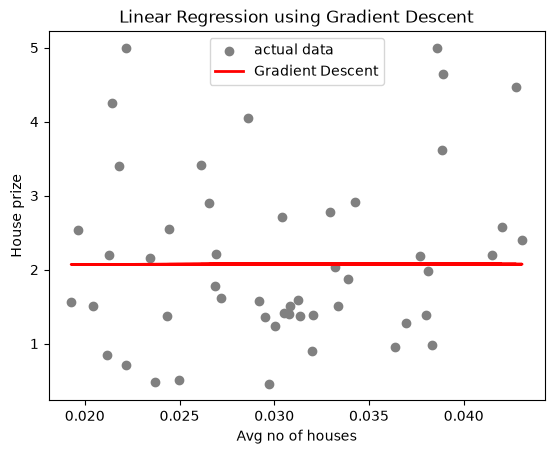

In [142]:
plt.scatter(X1_test[:50],y_test[:50],color='gray',label='actual data')
plt.plot(X1_test[:50],y_test_pred[:50],color='red',label='Gradient Descent',linewidth=2)
plt.xlabel('Avg no of houses')
plt.ylabel("House prize")
plt.title("Linear Regression using Gradient Descent")
plt.legend()
plt.show()

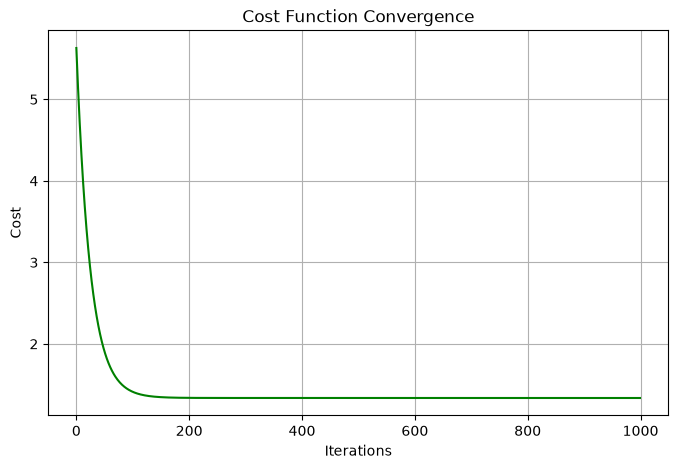

In [143]:
plt.figure(figsize=(8,5))
plt.plot(range(iterations),cost_history,color='green')
plt.title("Cost Function Convergence")
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

In [145]:
new=int(input("Enter the no of rooms:"))
new= (new-np.min(X))/((np.max(X))-(np.min(X)))
predicted_value=theta0+theta1*new
print(predicted_value)

2.071649294337224
